In [1]:
# %%
from core.Det import Det, DetData
import numpy as np
import matplotlib.pyplot as plt
from rich.table import Table
from rich import print
from hdf5storage import loadmat
import time
from core.AcqFunc import *

In [2]:
srv = DetData("10.20.22.230",7494)
dets = srv.findDet()
print(dets)
det = list(dets.items())[0][1]
srv.listen()

{'10.20.22.231': <core.Det.Det.Det object at 0x0000025B592F6510>}

In [3]:
# %% 状态信息
def dictPrint(d: dict, title="", k="", v=""):
    t = Table(title=title)
    t.add_column(k)
    t.add_column(v)
    [t.add_row(k, str(v)) for k, v in d.items()]
    print(t)
dictPrint(det.statusTemperature(), "温度")
dictPrint(det.statusPosition(0.0375), "位置")
dictPrint(det.statusPower(), "电源")
dictPrint(det.statusPowerSwitch(), "开关")
dictPrint(det.statusFanSpeed(), "风扇")

           温度            
┏━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃            ┃            ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ boardNum   │ 1          │
│ temperIO_0 │ 26.875     │
│ temperIO_1 │ 27.625     │
│ temper0_0  │ 26.2578125 │
│ temper0_1  │ 27.8359375 │
│ temper0_2  │ 29.2734375 │
│ temper0_3  │ 29.484375  │
└────────────┴────────────┘

      位置       
┏━━━━━━━┳━━━━━━━┓
┃       ┃       ┃
┡━━━━━━━╇━━━━━━━┩
│ pos0A │ False │
│ pos0B │ False │
│ pos0  │ 0.075 │
│ pos1A │ False │
│ pos1B │ False │
│ pos1  │ 0.0   │
└───────┴───────┘

         电源         
┏━━━━━━━━━┳━━━━━━━━━━┓
┃         ┃          ┃
┡━━━━━━━━━╇━━━━━━━━━━┩
│ voltage │ 23.95125 │
│ currnet │ 0.574    │
│ power   │ 13.75    │
└─────────┴──────────┘

            开关             
┏━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃        ┃                  ┃
┡━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ vcc12  │ True             │
│ laser1 │ True             │
│ laser0 │ True             │
│ vdd25  │ 11111111         │
│ opa    │ 1111111111111111 │
│ vbias  │ 11111111         │
└────────┴──────────────────┘

        风扇        
┏━━━━━━━━━━━┳━━━━━━┓
┃           ┃      ┃
┡━━━━━━━━━━━╇━━━━━━┩
│ fanNum    │ 1    │
│ fanSpeed0 │ 1472 │
└───────────┴──────┘

In [4]:
# %% 电源及参数设置
det.setPositionConfig([
    {"pos": 0, "en": 1, "polarity": 0, "clearPos": 1, "zeroShift": 0},
    {"pos": 1, "en": 0, "polarity": 0, "clearPos": 1, "zeroShift": 0}])
det.setPowerSwitch({
    "laser1": 0, "laser0": 0, "opa": 1, "vbias": 1, "vcc12": 1, "vdd25": 1})
det.DetectRegSet(0x0018, 0x600003FF)
det.setWinNum(4)

detector run

test3

ERROR:root:没有足够的帧用于重建


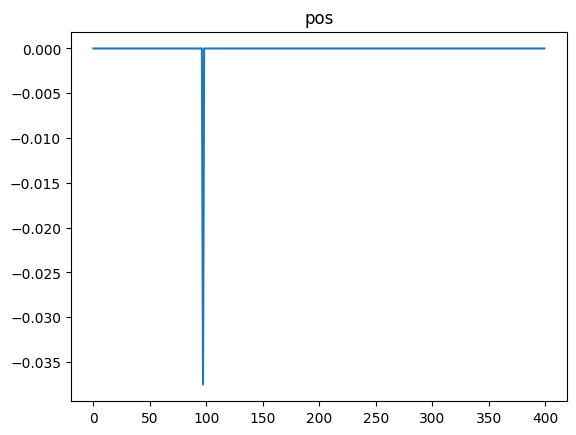

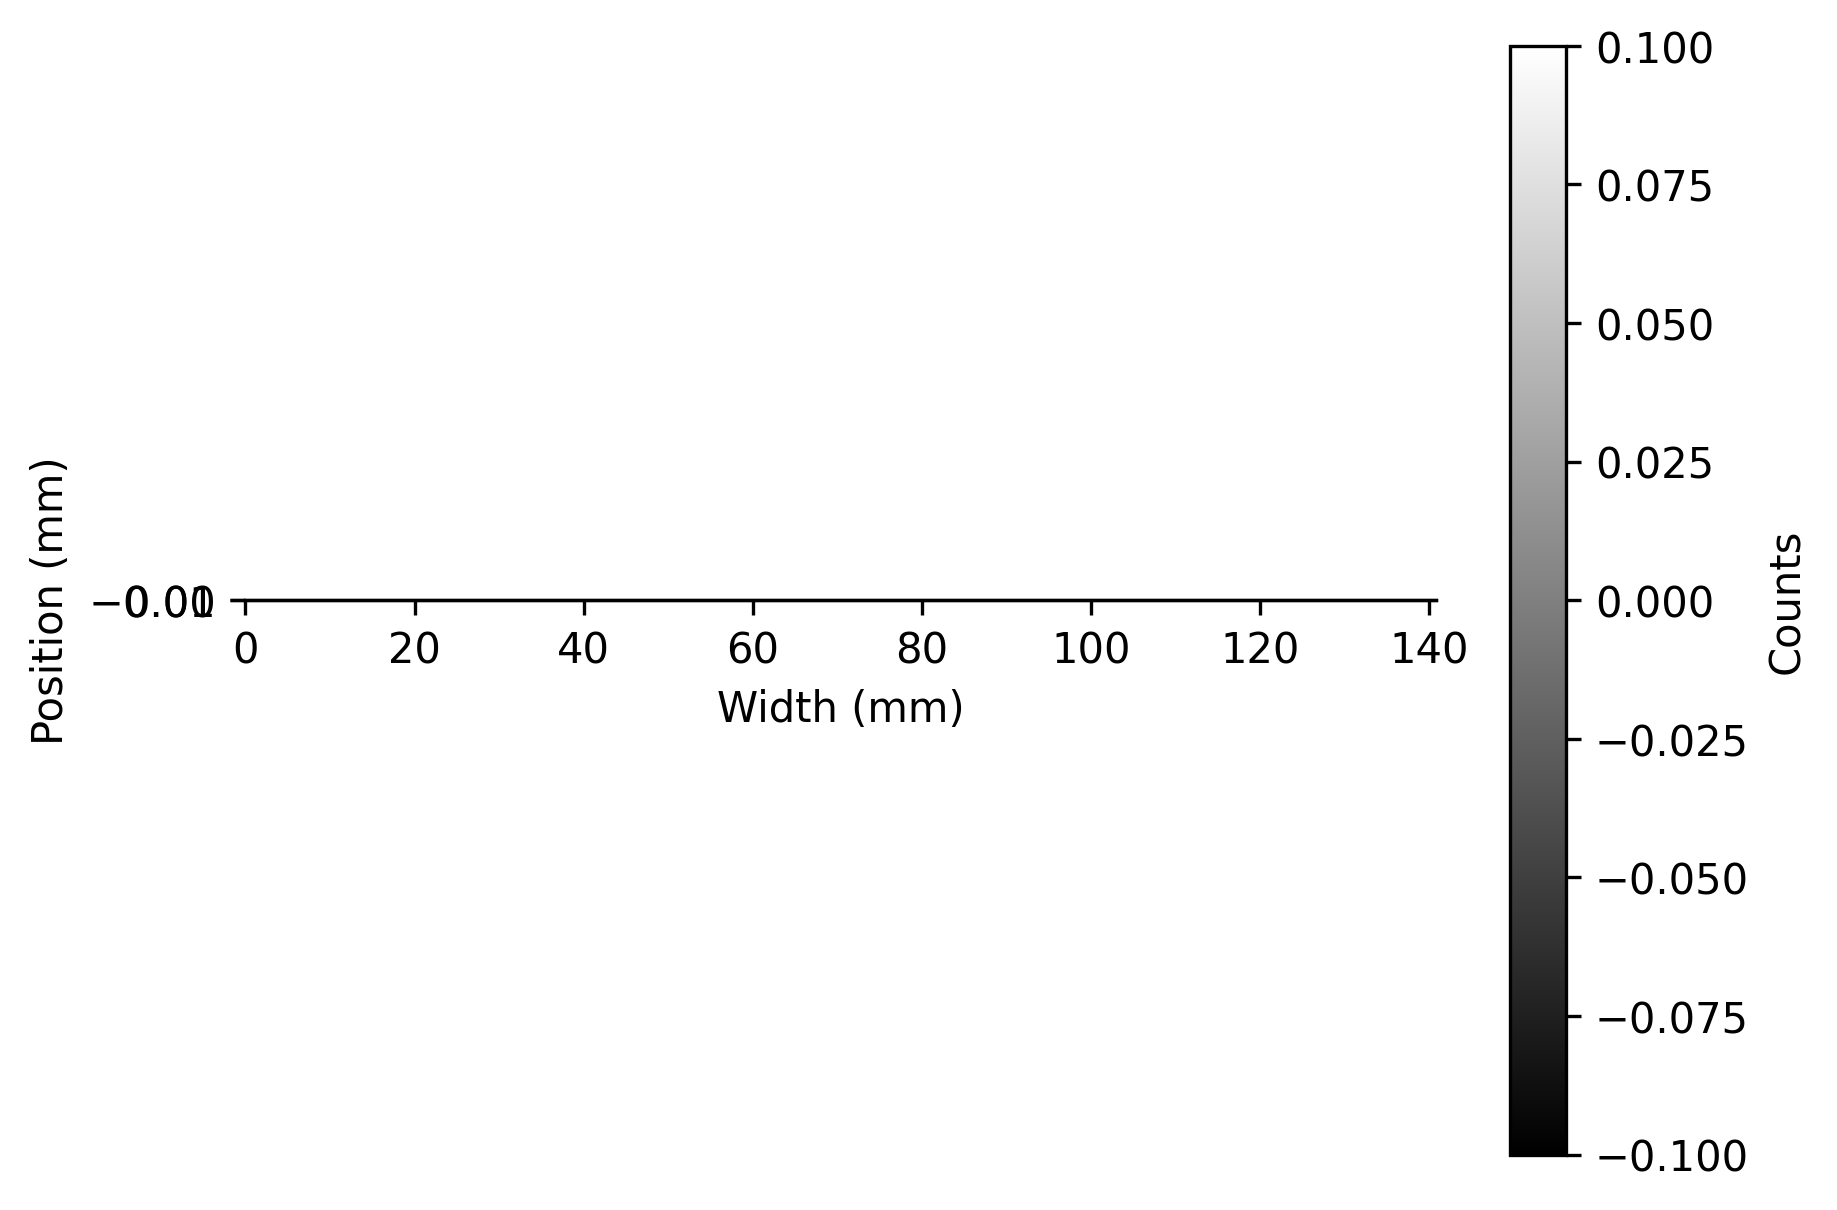

In [5]:
for i in range(1):
    # tube = f""
    # tube = f"_70kV_10mA"
    # filter = f"_0.3mmCu+0.3mmSn"
    # speed = f"_150mmps"
    name = f"test3"

    subname = f"{name}"
    det.setWinRange(0, 0, 80)
    # time.sleep(4)
    print("detector run")
    # time.sleep(1)
    data = histAcqNoMove(det, cnt=None, time=4, interval = int(10 * 10))
    saveHist(data, subname, None)
    print(subname)
    showHist(
        data,
        pos_en=True,
        pos_step=0.0375,
        cal_sel=(400, 450),
        rate=1400/20,
        log_en=False,
        pos_limit=(0, 0),
        caxis=(0, 0),
        save_png=""
    )

In [8]:
data.shape

(400, 256)

In [ ]:
for i in range(1):
    # tube = f""
    tube = f"_75kV_110mA"
    # filter = f"_0.3mmCu+0.3mmSn"
    filter = f"_25mmAl"
    speed = f"_37.5mmps"
    freq = 500
    name = f"test2{speed}{filter}{tube}_{freq}hz"

    subname = f"{name}"
    det.setWinRange(0, 0, 99)
    det.setWinRange(1, 6, 21)
    det.setWinRange(2, 22, 40)
    det.setWinRange(3, 0, 90)
    print("detector run")
    data = thrAcqNoMove(det, cnt=None, time=8, interval = int(1000/freq * 10))
    saveThr(data, subname)
    print(subname)
    data2 = {
        "pos0h": data["pos0h"],
        "data": data["data"].reshape((data["data"].shape[0], -1, data["data"].shape[3]))
    }
    showHist(
        data2,
        pos_en=True,
        pos_step=0.0375,
        cal_sel=(400, 450),
        rate=1400/20,
        log_en=False,
        pos_limit=(0, 0),
        caxis=(0, 0),
        save_png=""
    )

In [ ]:
data.shape

(400, 256)

In [13]:
data

array([[(1610613249, 0, 0, 0, 0, 3,   0,   0, 162, [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
        (         1, 0, 0, 0, 0, 3,   0,   1, 162, [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
        (         1, 0, 0, 0, 0, 3,   0,   2, 162, [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
        ...,
        (         1, 0, 0, 0, 0, 3,   0, 253, 162, [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [12]:
plt.imshow(data.astype(np.float32))
plt.colorbar()

TypeError: Cannot cast array data from dtype([('flag', '<u4'), ('pos0h', '<i4'), ('pos0t', '<i4'), ('pos1h', '<i4'), ('pos1t', '<i4'), ('info', '<u4'), ('frame', '<u4'), ('idx', '<u2'), ('dLen', '<u2'), ('data', '<u2', (81,))]) to dtype('float32') according to the rule 'unsafe'